Import `podio` reader to read root file.

In [1]:
from podio.root_io import Reader

Module libc not found.


Welcome to JupyROOT 6.28/06


/opt/podio/v00-17-02/python/podio/EventStore.py:4: FutureWarning: The EventStore based I/O model is deprecated and will be removed. Switch to the Frame based model.
  warnings.warn("The EventStore based I/O model is deprecated and will be removed. Switch to the Frame based model.",


Open root file generated by simple_digi. 
Replace the path with personal data. 

In [2]:
reader = Reader( "/data/home/lixp/sim/simple_digi.root" )

# Process One Event
Take the 0th event for demonstration.

In [3]:
event_to_proc = 0

events = reader.get( "events" )
event  = events[event_to_proc]
hits   = event.get( "TpcHits" )

See the number of hits. 

In [4]:
print(f"Number of hits = {len(hits)}")

Number of hits = 237


Convert raw hits collection to numpy matrix.

In [5]:
import numpy as np
from RecoUtils import decodeRawHits

dhits =  decodeRawHits(hits)

Info in <TGeoManager>: Changing system of units to Geant4 units (mm, ns, MeV).


Rebuild 3D hits from 2d hits.

In [6]:
from Hit3DBuilder import build3d

search_band = 100
tor = 15

pairs = build3d(dhits.x_hits, dhits.y_hits, search_band, tor)

Convert 3D hit pairs to 3D matrix.

In [7]:
drift_velocity = 6
pair_mapper = np.frompyfunc(lambda pair: (pair.x(), pair.y(), pair.time() / 1000 * drift_velocity), 1, 3)

hits_3d = np.stack(pair_mapper(np.array(pairs)), axis=1)
print(hits_3d)

[[-233.72065577182147 6.2036830467356605 0.08369323253631591]
 [-227.1159059055223 5.487854115802663 0.771805778503418]
 [-226.7535554177055 5.487854115802663 0.7873494873046876]
 [-209.33374935284138 4.537186877432769 2.695635864257812]
 [-210.33443751991734 4.537186877432769 2.7030899047851564]
 [-208.65291928823603 4.537186877432769 2.7205329895019528]
 [-175.354915633134 3.51575669469604 6.397985229492187]
 [-174.31998722467256 3.51575669469604 6.430217651367187]
 [-173.75846157377063 3.51575669469604 6.4401943359375]
 [-139.6046212610511 2.489976878094541 10.252761474609375]
 [-138.57816159826845 2.489976878094541 10.310598999023437]
 [-127.5613485590767 1.5237981719873117 11.438700439453125]
 [-88.54952671851429 -0.487986637582118 15.71265380859375]
 [-87.62405006255301 -0.487986637582118 15.7304296875]
 [-86.64643522088949 0.5076476676745287 15.958618652343748]
 [-40.04382775140852 -1.3029885023714476 21.07475537109375]
 [-37.18952160957919 -1.3029885023714476 21.091080322265626

A helper function to plot 3D scatter.

In [8]:
%matplotlib widget
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d
from RecoUtils import clusterCenter

def plot3d(hits_3d, color = "blue", labels = None, hide_distinct = False, ax = None):
    if ax is None:
        fig = plt.figure()
        ax = plt.axes(projection="3d")
    ax.set_xlabel('X', fontweight='bold')
    ax.set_ylabel('Y', fontweight='bold')
    ax.set_zlabel('Z', fontweight='bold')
    if labels is None:
        ax.scatter3D(hits_3d[:, 0], hits_3d[:, 1], hits_3d[:, 2], color=color)
    else:
        ax.scatter3D(hits_3d[:, 0], hits_3d[:, 1], hits_3d[:, 2], c=labels)
        centers = clusterCenter(hits_3d, labels)
        for c in centers:
            if hide_distinct and c[3] == -1:
                break
            ax.text(c[0], c[1], c[2], int(c[3]))

View rebuilt 3D points.

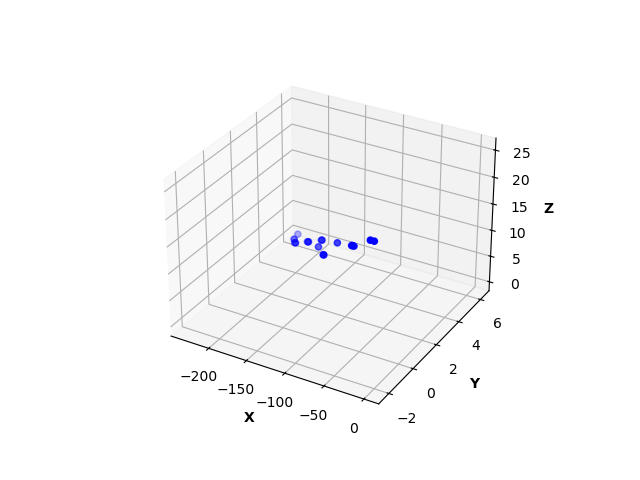

In [9]:
plot3d(hits_3d)
plt.show()

Cluster and view the result. 

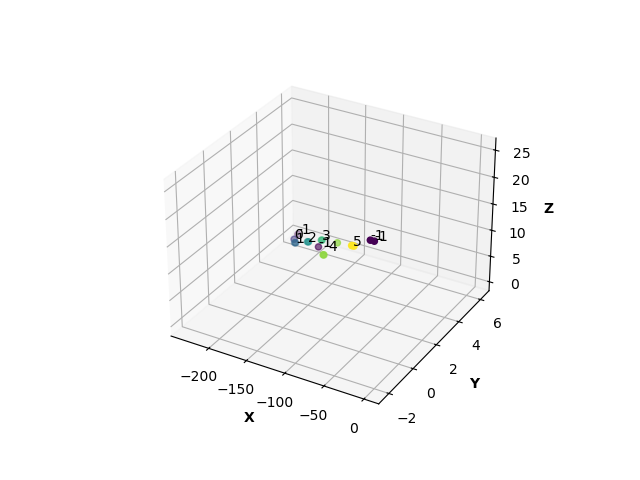

In [10]:
from sklearn.cluster import DBSCAN

clusters = DBSCAN(eps=3, min_samples=2).fit(hits_3d)
labels = clusters.labels_

plot3d(hits_3d, labels=labels)
plt.show()

# Some more events

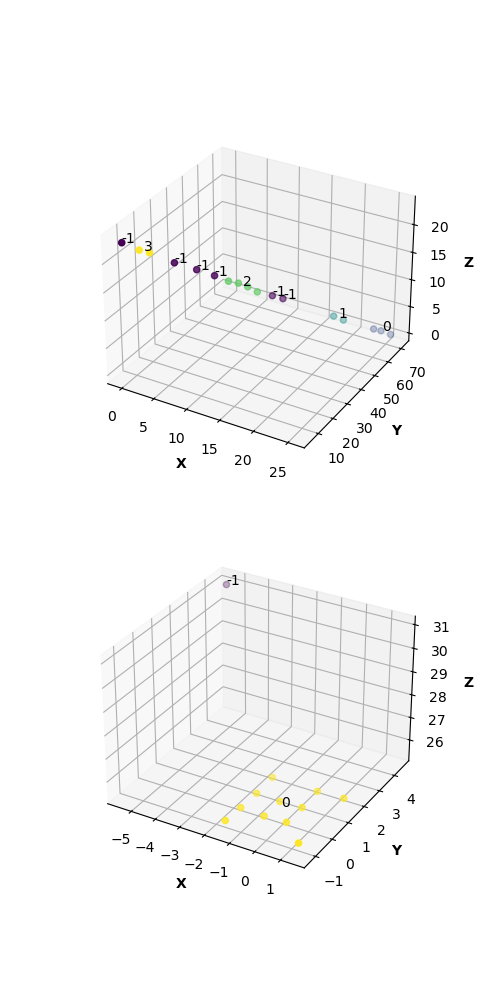

In [11]:
events_to_proc = range(1, 3)
n = len(events_to_proc)
fig = plt.figure(figsize=(5, 5 * n))
for i in range(n):
    event  = events[events_to_proc[i]]
    hits   = event.get( "TpcHits" )
    dhits =  decodeRawHits(hits)
    pairs = build3d(dhits.x_hits, dhits.y_hits, search_band, tor)
    hits_3d = np.stack(pair_mapper(np.array(pairs)), axis=1)
    clusters = DBSCAN(eps=3, min_samples=2).fit(hits_3d)
    labels = clusters.labels_
    ax = fig.add_subplot(n, 1, 1 + i, projection="3d")
    plot3d(hits_3d, labels=labels, ax=ax)
plt.show()

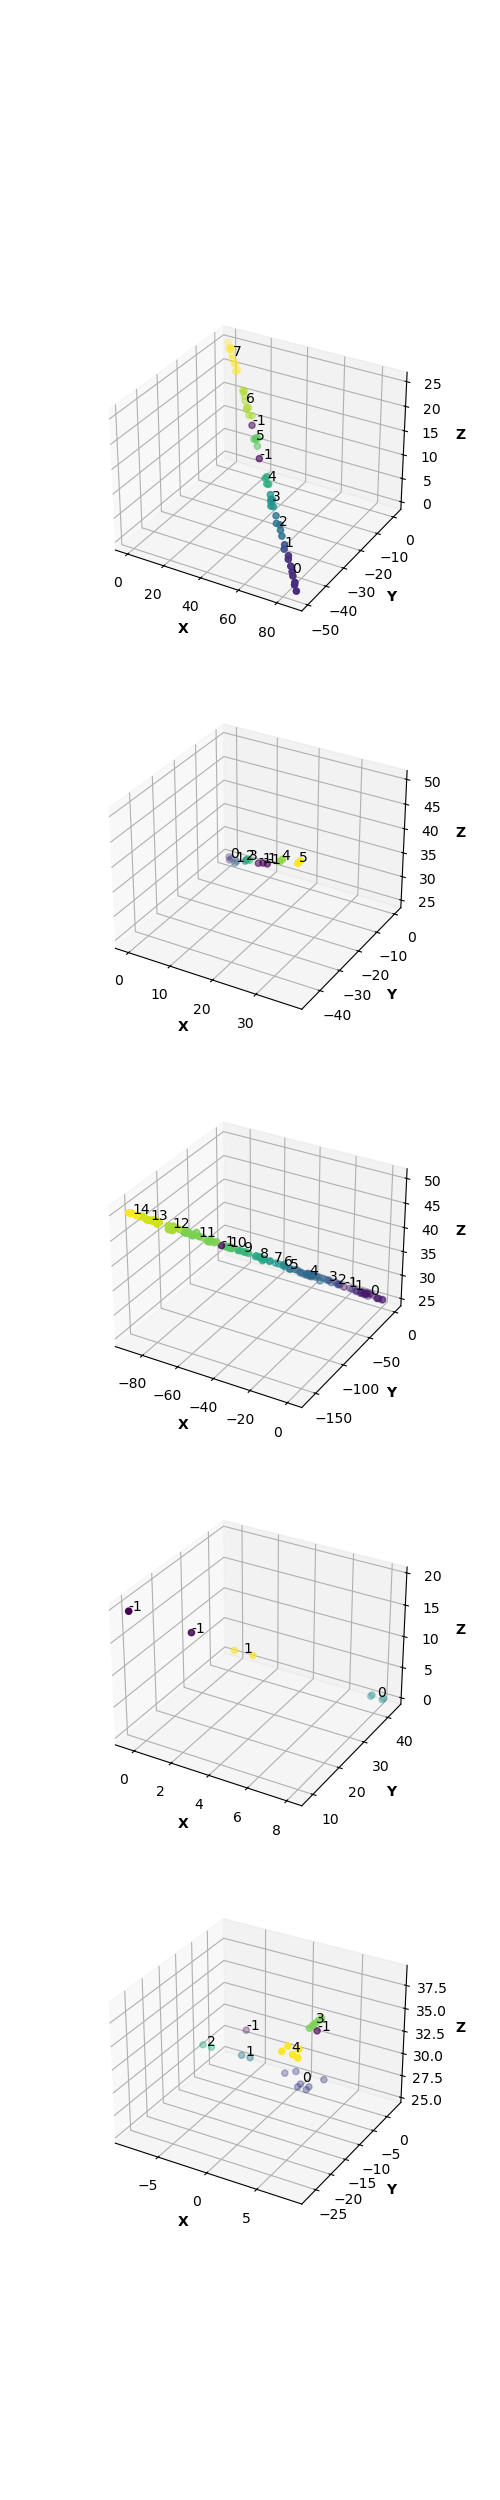

In [12]:
events_to_proc = range(10, 15)
n = len(events_to_proc)
fig = plt.figure(figsize=(5, 5 * n))
for i in range(n):
    event  = events[events_to_proc[i]]
    hits   = event.get( "TpcHits" )
    dhits =  decodeRawHits(hits)
    pairs = build3d(dhits.x_hits, dhits.y_hits, search_band, tor)
    hits_3d = np.stack(pair_mapper(np.array(pairs)), axis=1)
    clusters = DBSCAN(eps=3, min_samples=2).fit(hits_3d)
    labels = clusters.labels_
    ax = fig.add_subplot(n, 1, 1 + i, projection="3d")
    plot3d(hits_3d, labels=labels, ax=ax)
plt.show()